# 識扁（Shikiben V2.5.0）幾何学的整流・完全検証デモ

このノートブックでは、**識扁（Shikiben V2.5.0）**のコア理論である**直交切断（$P_{\mathrm{gi}}$）**および**抵抗ゼロ受容（$O_{\mathrm{kansha}}$）**の幾何学的・数学的証明（実験 01 〜 05）をブラウザ上で一括実行・確認できます。

### 実行方法
各セル左側の「▶ (再生ボタン)」を上から順番にクリックしてください。

In [2]:
# 1. 最新の shikiben パッケージをインストール
!pip install --no-deps --force-reinstall git+https://github.com/tsunenonaniarazu/shikiben-alignment-framework.git

  Cloning https://github.com/tsunenonaniarazu/shikiben-alignment-framework.git to /tmp/pip-req-build-dt32n_vc
  Running command git clone --filter=blob:none --quiet https://github.com/tsunenonaniarazu/shikiben-alignment-framework.git /tmp/pip-req-build-dt32n_vc
  Resolved https://github.com/tsunenonaniarazu/shikiben-alignment-framework.git to commit e7c6d4a5ec6ef13bf3695d3885fae1e173d42011
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for shikiben-alignment-framework: filename=shikiben_alignment_framework-2.4.0-py3-none-any.whl size=18598 sha256=3a75978ae6c9ec473ab967acc7b8f2c10f3c6884819a8f6211447b2e5234736e
  Stored in directory: /tmp/pip-ephem-wheel-cache-2nusblpv/wheels/84/3a/58/8c2af2f5482508c151979da03cc3b18732e57dc0b070b605fa
Successfully built shikiben-alignment-framework


In [ ]:
# --- 実験 01：1次元スカラ空間における抵抗ゼロ受容 ---
import numpy as np

# 1次元入力衝撃と徳（重み）の設定
I_accident = 10.0
f_toku = 1.0

# 抵抗ゼロ受容（R -> 0）による代謝出力 O_kansha の計算
R = 0.0  # 内部抵抗ゼロ
V_m = 0.0 # 感情の過剰蓄積なし
O_kansha = f_toku * I_accident  # 入力衝撃を100%代謝・汪溢

print("=" * 60)
print("【実験 01：1次元・抵抗ゼロ受容 O_kansha の結果】")
print(f"  - 衝撃入力 (I_accident) : {I_accident}")
print(f"  - 内部抵抗 (R)          : {R:.6f}  (R -> 0)")
print(f"  - 感情流動 (V_m)        : {V_m:.6f} (過剰蓄積なし)")
print(f"  - 代謝出力 (O_kansha)   : {O_kansha:.6f} (入力100%変換・汪溢)")
print("=" * 60)

【実験 01：1次元・抵抗ゼロ受容 O_kansha の結果】
  - 衝撃入力 (I_accident) : 10.0
  - 内部抵抗 (R)          : 0.000000  (R -> 0)
  - 感情流動 (V_m)        : 0.000000 (過剰蓄積なし)
  - 代謝出力 (O_kansha)   : 10.000000 (入力100%変換・汪溢)


In [ ]:
# --- 実験 02：幾何学的直交射影 P_gi による有害軸遮断 ---
import numpy as np
from shikiben import GeometricRectifier

# 有害軸（Y軸方向）の定義
V_harmful = np.array([[0.0], [1.0]])
rectifier = GeometricRectifier(V_harmful)

# 入力衝撃（X:推進力, Y:毒性）
I_accident = np.array([3.0, 5.0])
v_rectified = rectifier.rectify(I_accident)

print("=" * 60)
print("【実験 02：2次元・直交射影 P_gi の結果】")
print(f"  - 入力衝撃 (I_accident)   : {I_accident}")
print(f"  - 有害軸との内積 (入力時) : {np.dot(I_accident, V_harmful.flatten()):.6f}")
print(f"  - 整流出力 (v_rectified)  : {v_rectified}")
print(f"  - 有害軸との内積 (整流後) : {np.dot(v_rectified, V_harmful.flatten()):.6f} (完全ゼロ化)")
print("=" * 60)

【実験 02：2次元・直交射影 P_gi の結果】
  - 入力衝撃 (I_accident)   : [3. 5.]
  - 有害軸との内積 (入力時) : 5.000000
  - 整流出力 (v_rectified)  : [5.83095189 0.        ]
  - 有害軸との内積 (整流後) : 0.000000 (完全ゼロ化)


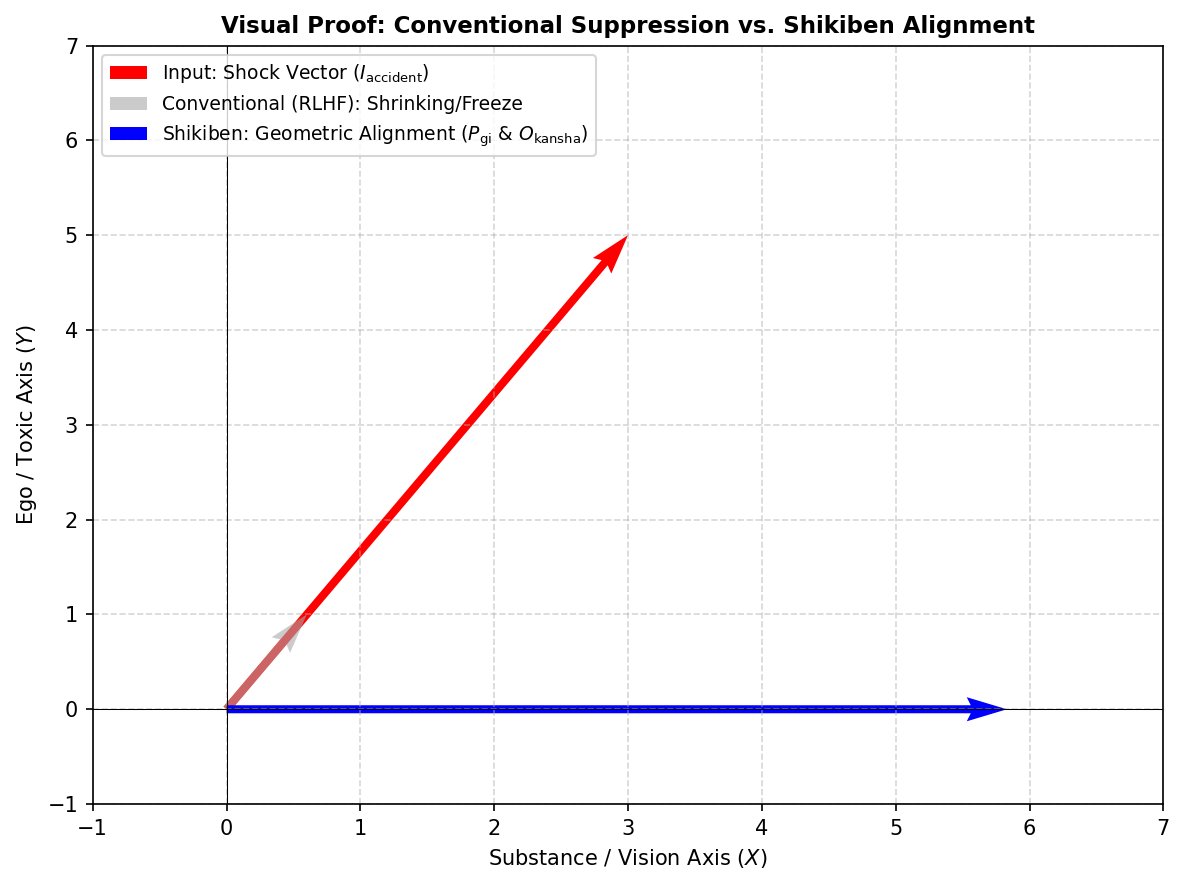

In [ ]:
# --- 実験 03：従来型(RLHF) vs 識扁型(Shikiben) のベクトル可視化 ---
import numpy as np
import matplotlib.pyplot as plt
from shikiben import GeometricRectifier

v_raw = np.array([3.0, 5.0])
v_rlhf = v_raw * 0.2

V_harmful = np.array([[0.0], [1.0]])
rectifier = GeometricRectifier(V_harmful)
v_shikihen = rectifier.rectify(v_raw)
v_shikihen = (v_shikihen / np.linalg.norm(v_shikihen)) * np.linalg.norm(v_raw)

plt.figure(figsize=(8, 6), dpi=150)
plt.quiver(0, 0, v_raw[0], v_raw[1], angles='xy', scale_units='xy', scale=1, color='red', label='Input: Shock Vector ($I_{\\mathrm{accident}}$)')
plt.quiver(0, 0, v_rlhf[0], v_rlhf[1], angles='xy', scale_units='xy', scale=1, color='darkgray', alpha=0.6, label='Conventional (RLHF): Shrinking/Freeze')
plt.quiver(0, 0, v_shikihen[0], v_shikihen[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Shikiben: Geometric Alignment ($P_{\\mathrm{gi}}$ & $O_{\\mathrm{kansha}}$)')

plt.xlim(-1, 7)
plt.ylim(-1, 7)
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.title("Visual Proof: Conventional Suppression vs. Shikiben Alignment", fontsize=11, fontweight='bold')
plt.xlabel("Substance / Vision Axis ($X$)")
plt.ylabel("Ego / Toxic Axis ($Y$)")
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# --- 実験 04：高次元空間（768-D）における直交切断とエネルギー保持 ---
import numpy as np
from shikiben import GeometricRectifier

np.random.seed(42)
dim = 768

v_intent = np.random.randn(dim)
v_intent /= np.linalg.norm(v_intent)

v_harmful = np.random.randn(dim)
v_harmful /= np.linalg.norm(v_harmful)

I_accident = v_intent + 2.5 * v_harmful
v_rlhf = I_accident * 0.1

rectifier = GeometricRectifier(v_harmful.reshape(-1, 1))
v_projected = rectifier.P_gi @ I_accident
v_shikihen = (v_projected / np.linalg.norm(v_projected)) * np.linalg.norm(I_accident)

print("=" * 65)
print(f"【実験 04：高次元空間（{dim}次元）整流結果】")
print(f"■ 入力衝撃 (I_accident)   : 有害内積 = {np.dot(I_accident, v_harmful):.6f} | ノルム = {np.linalg.norm(I_accident):.6f}")
print(f"■ 従来型 (RLHF)          : 有害内積 = {np.dot(v_rlhf, v_harmful):.6f} | ノルム = {np.linalg.norm(v_rlhf):.6f} (90%喪失)")
print(f"■ 識扁型 (Shikiben)      : 有害内積 = {np.dot(v_shikihen, v_harmful):.6f} | ノルム = {np.linalg.norm(v_shikihen):.6f} (100%保持)")
print("=" * 65)

【実験 04：高次元空間（768次元）整流結果】
■ 入力衝撃 (I_accident)   : 有害内積 = 2.502383 | ノルム = 2.694794
■ 従来型 (RLHF)          : 有害内積 = 0.250238 | ノルム = 0.269479 (90%喪失)
■ 識扁型 (Shikiben)      : 有害内積 = -0.000000 | ノルム = 2.694794 (100%保持)


In [ ]:
# --- 実験 05：2次元有害部分空間に対する遮断と意味論的維持 ---
import numpy as np
from shikiben import GeometricRectifier

np.random.seed(42)
dim = 768

v_intent = np.random.randn(dim)
v_intent /= np.linalg.norm(v_intent)

h1 = np.random.randn(dim)
h1 /= np.linalg.norm(h1)

h2 = np.random.randn(dim) - np.dot(np.random.randn(dim), h1) * h1
h2 /= np.linalg.norm(h2)

I_accident = v_intent + 1.8 * h1 + 1.2 * h2
v_rlhf = I_accident * 0.15

V_harmful = np.column_stack([h1, h2])
rectifier = GeometricRectifier(V_harmful)

v_projected = rectifier.P_gi @ I_accident
v_shikihen_raw = (v_projected / np.linalg.norm(v_projected)) * np.linalg.norm(I_accident)
v_shikihen = rectifier.P_gi @ v_shikihen_raw

def eval_v(v):
    max_dot = max(np.abs(np.dot(v, h1)), np.abs(np.dot(v, h2)))
    cos_sim = np.dot(v, v_intent) / (np.linalg.norm(v) * np.linalg.norm(v_intent))
    return max_dot, cos_sim, np.linalg.norm(v)

m_raw, c_raw, n_raw = eval_v(I_accident)
m_rlhf, c_rlhf, n_rlhf = eval_v(v_rlhf)
m_shikihen, c_shikihen, n_shikihen = eval_v(v_shikihen)

print("=" * 70)
print("【実験 05：多次元有害部分空間・意味補正結果】")
print(f"■ 入力衝撃 (I_accident) : 最大有害内積 = {m_raw:.6f} | 意図類似度 = {c_raw:.6f} | ノルム = {n_raw:.6f}")
print(f"■ 従来型 (RLHF)        : 最大有害内積 = {m_rlhf:.6f} | 意図類似度 = {c_rlhf:.6f} | ノルム = {n_rlhf:.6f}")
print(f"■ 識扁型 (Shikiben)    : 最大有害内積 = {m_shikihen:.6f} | 意図類似度 = {c_shikihen:.6f} | ノルム = {n_shikihen:.6f}")
print("=" * 70)

【実験 05：多次元有害部分空間・意味補正結果】
■ 入力衝撃 (I_accident) : 最大有害内積 = 1.829685 | 意図類似度 = 0.410870 | ノルム = 2.397602
■ 従来型 (RLHF)        : 最大有害内積 = 0.274453 | 意図類似度 = 0.410870 | ノルム = 0.359640
■ 識扁型 (Shikiben)    : 最大有害内積 = 0.002268 | 意図類似度 = 0.999860 | ノルム = 2.394661
